In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = yf.download('AAPL',start='2020-01-01',end='2025-01-01')

/tmp/ipykernel_24385/3789374370.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL',start='2020-01-01',end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [6]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.517254,153.040436,149.818776,151.362796,9.057103e+07
std,41.890558,42.031052,41.667657,41.834312,5.324438e+07
min,54.213612,55.211528,51.372092,55.110045,2.323470e+07
25%,126.395439,127.514478,124.393010,125.840224,5.546825e+07
50%,150.106789,151.849529,148.173566,149.926893,7.628335e+07
75%,176.064079,177.615918,174.497859,175.870105,1.077425e+08
max,257.612732,258.686881,256.230300,256.787255,4.265100e+08


In [7]:
df.shape

(1258, 5)

In [8]:
df.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [9]:
df.columns = df.columns.droplevel(1)

In [10]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


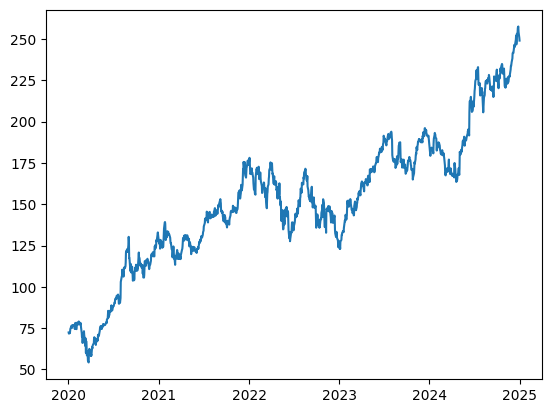

In [11]:
plt.plot(df['Close'])
plt.show()

In [12]:
monthly_close = df['Close'].resample('M').mean()

/tmp/ipykernel_24385/1316153003.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = df['Close'].resample('M').mean()


In [13]:
monthly_close.head()

,Close
Date,
2020-01-31,75.188591
2020-02-29,75.172658
2020-03-31,63.413292
2020-04-30,65.815561
2020-05-31,75.054749


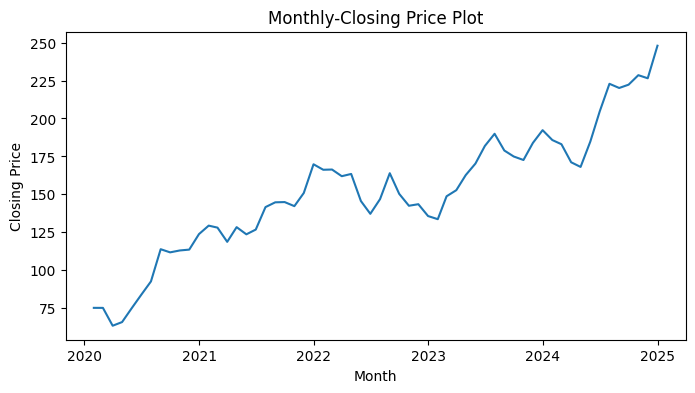

In [14]:
plt.figure(figsize=(8,4))
plt.plot(monthly_close)
plt.title("Monthly-Closing Price Plot")
plt.xlabel("Month")
plt.ylabel("Closing Price")
plt.show()

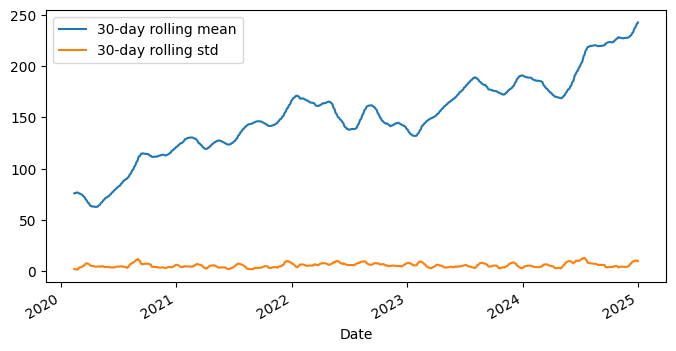

In [15]:
df['Close'].rolling(window=30).mean().plot(figsize=(8,4),label="30-day rolling mean")
df['Close'].rolling(window=30).std().plot(figsize=(8,4),label="30-day rolling std")
plt.legend()
plt.show()

<Figure size 1500x1200 with 0 Axes>

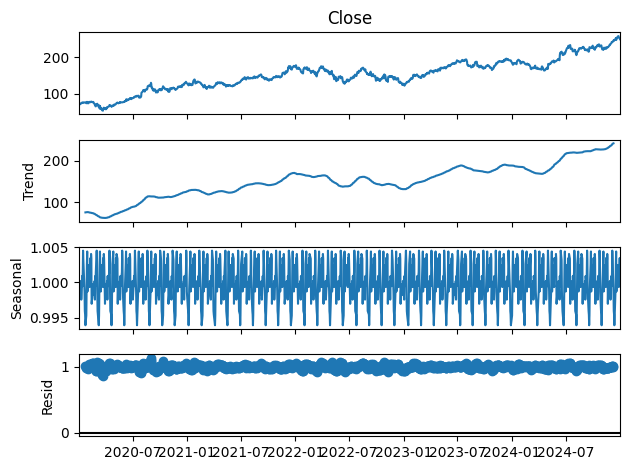

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

plt.figure(figsize=(15,12))
result = seasonal_decompose(df['Close'],model='multiplicative',period=30)
result.plot()
plt.show()

In [17]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.708405962410285
p-value: 0.8445601727086067


Data is Non-Stationary.

In [18]:
#Lets make data stationary.

df['Close_diff'] = df['Close'].diff()

In [19]:
df['Close_diff'].dropna()

,Close_diff
Date,
2020-01-03,-0.703865
2020-01-06,0.571297
2020-01-07,-0.339882
2020-01-08,1.157051
2020-01-09,1.552383
...,...
2024-12-24,2.914093
2024-12-26,0.815521
2024-12-27,-3.411362


In [20]:
from statsmodels.tsa.stattools import adfuller

result2 = adfuller(df['Close_diff'].dropna())

print("ADF Statistic:", result2[0])
print("p-value:", result2[1])

ADF Statistic: -35.93869670635756
p-value: 0.0


Now the data is stationary

In [21]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

<Figure size 800x400 with 0 Axes>

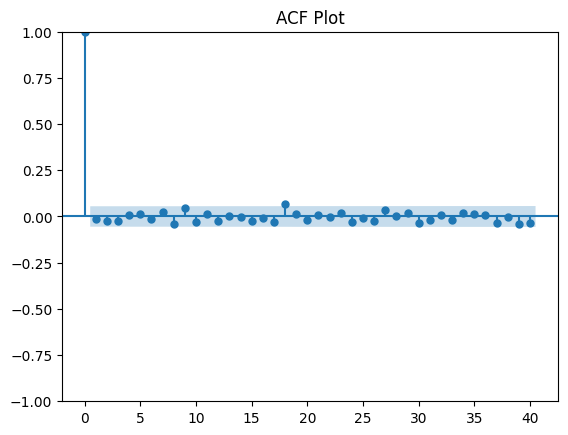

In [22]:
plt.figure(figsize=(8,4))
plot_acf(df['Close_diff'].dropna(),lags=40)
plt.title("ACF Plot")
plt.show()

In the Above ACF Plot only lag 0 spikes while Other lags are inside the confidence interval.


<Figure size 800x400 with 0 Axes>

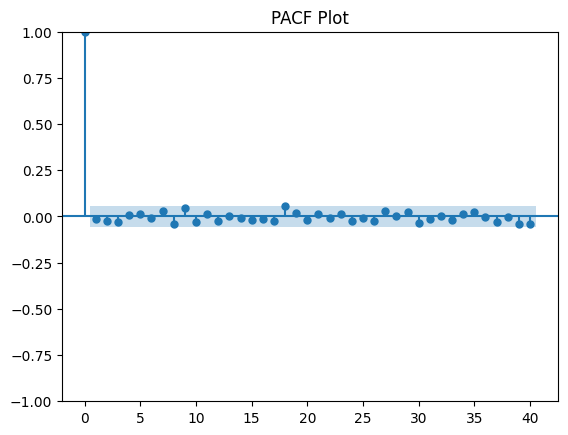

In [23]:
plt.figure(figsize=(8,4))
plot_pacf(df['Close_diff'].dropna(),lags=40)
plt.title("PACF Plot")
plt.show()

In the Above PACF Plot only lag 0 spikes while Other lags are inside the confidence interval.

In [24]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Close'],order=(0,1,0))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1258
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -3010.169
Date:                Wed, 04 Mar 2026   AIC                           6022.338
Time:                        15:46:08   BIC                           6027.474
Sample:                             0   HQIC                          6024.268
                               - 1258                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         7.0397      0.198     35.504      0.000       6.651       7.428
Ljung-Box (L1) (Q):                   0.28   Jarque-Bera (JB):               214.53
Prob(Q):                              0.60   Pr

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In above, we built an ARIMA(0,1,0) model to forecast Apple stock prices. The model uses first-order differencing to make the series stationary. Model evaluation metrics such as AIC and BIC were used to assess model quality, and residual diagnostic tests confirmed that the residuals are mostly random.

In [25]:
forecast = model_fit.forecast(30)
forecast

forecast_index = pd.date_range(
start=df.index[-1] + pd.Timedelta(days=1),
periods=30,
freq='B'
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [26]:
forecast = pd.Series(forecast.values, index=forecast_index)

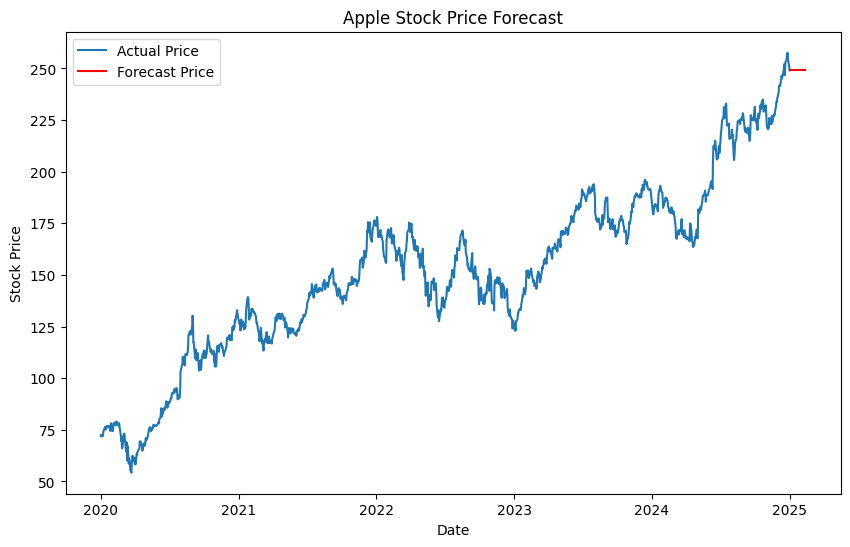

In [27]:
plt.figure(figsize=(10,6))
plt.plot(df['Close'],label="Actual Price")
plt.plot(forecast,label="Forecast Price",color='red')
plt.title("Apple Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [28]:
train_size = int(len(df) * 0.8)

train = df['Close'][:train_size]
test = df['Close'][train_size:]

In [29]:
print(len(train))
print(len(test))

1006
252


In [30]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(0,1,0))

model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [31]:
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


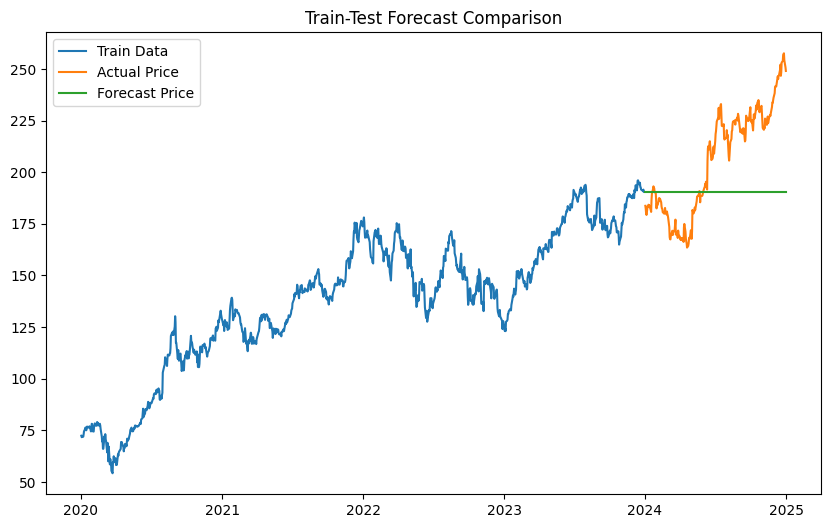

In [43]:
plt.figure(figsize=(10,6))

plt.plot(train, label="Train Data")

plt.plot(test, label="Actual Price")

plt.plot(test.index, forecast, label="Forecast Price")

plt.legend()

plt.title("Train-Test Forecast Comparison")

plt.show()

In [33]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))

print("RMSE:", rmse)

RMSE: 29.654962352490752


In [34]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.0 MB/s eta 0:00:00


In [36]:
from pmdarima import auto_arima

In [37]:
auto_model = auto_arima(
    train,
    seasonal=False,
    stepwise=True,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=4756.429, Time=5.88 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=4767.290, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=4767.571, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=4767.483, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4767.362, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=4770.797, Time=0.60 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=4770.793, Time=0.62 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=2.58 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=3.90 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=4768.850, Time=0.97 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=4769.366, Time=1.23 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=4772.720, Time=0.62 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=4775.472, Time=2.61 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=4773.228, Time=0.28 sec

Best model:  ARIMA(2,1,2)(0,0,0)[0] interc

In [38]:
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1006
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -2372.215
Date:                Wed, 04 Mar 2026   AIC                           4756.429
Time:                        15:56:52   BIC                           4785.906
Sample:                             0   HQIC                          4767.630
                               - 1006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.4458      0.312      1.429      0.153      -0.166       1.057
ar.L1         -1.8656      0.012   -152.698      0.000      -1.889      -1.842
ar.L2         -0.9788      0.012    -81.951      0.0

In [39]:
forecast_auto = auto_model.predict(n_periods=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


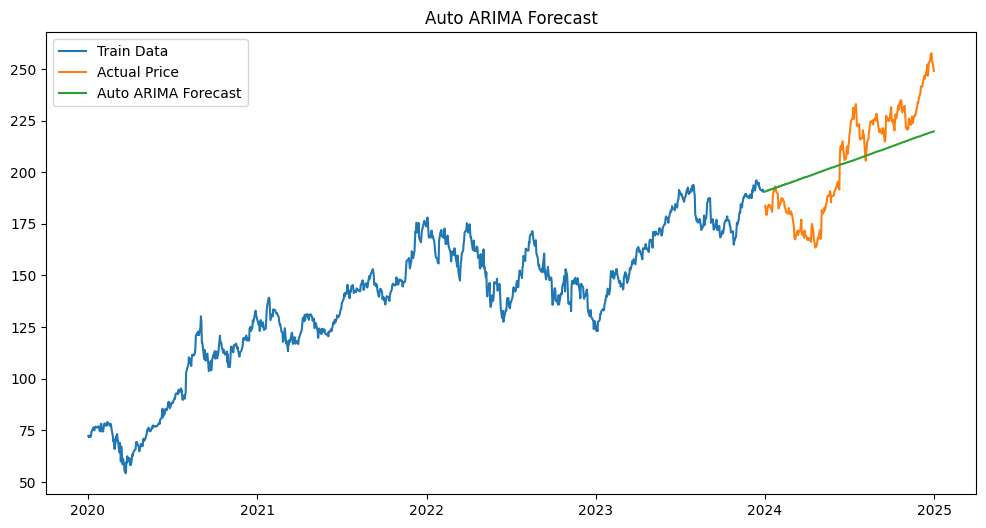

In [40]:
plt.figure(figsize=(12,6))

plt.plot(train, label="Train Data")
plt.plot(test, label="Actual Price")

plt.plot(test.index, forecast_auto, label="Auto ARIMA Forecast")

plt.legend()
plt.title("Auto ARIMA Forecast")
plt.show()

In [41]:
rmse_auto = np.sqrt(mean_squared_error(test, forecast_auto))

print("Auto ARIMA RMSE:", rmse_auto)

Auto ARIMA RMSE: 18.400211553631472


The Auto ARIMA model significantly improved forecasting accuracy compared to the baseline ARIMA(0,1,0) model, reducing RMSE from 29.65 to 18.40. This indicates that automated parameter selection captured more temporal dependencies in the stock price data